In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as p
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.datasets import cifar10
from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from keras.layers import Dense, Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-05-08 20:58:39.753390: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778273920.115127      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778273920.221610      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778273921.067543      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778273921.067582      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778273921.067585      25 computation_placer.cc:177] computation placer alr

# Load Dataset

In [2]:
(X_train, y_train), (X_test,y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 81s 0us/step


In [3]:
X_train.shape, y_train.shape

((50000, 32, 32, 3), (50000, 1))

In [4]:
np.unique(y_train)

# It means in this CIFAR-10 have 10 classes (e.g., frog, airplane, cat, etc.)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

# Train test split 

In [5]:
X_train,X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

Printing out the dimension of our training, testing and validation datasets

In [6]:
print('Train Images Shape: ', X_train.shape)
print('Train labels Shape: ', y_train.shape)

print('\nValidation Images Shape: ', X_valid.shape)
print('Validation Labels Shape: ', y_valid.shape)

print('\nTest Images Shape: ', X_test.shape)
print('Test Labels Shape: ', y_test.shape)

Train Images Shape:  (45000, 32, 32, 3)
Train labels Shape:  (45000, 1)

Validation Images Shape:  (5000, 32, 32, 3)
Validation Labels Shape:  (5000, 1)

Test Images Shape:  (10000, 32, 32, 3)
Test Labels Shape:  (10000, 1)


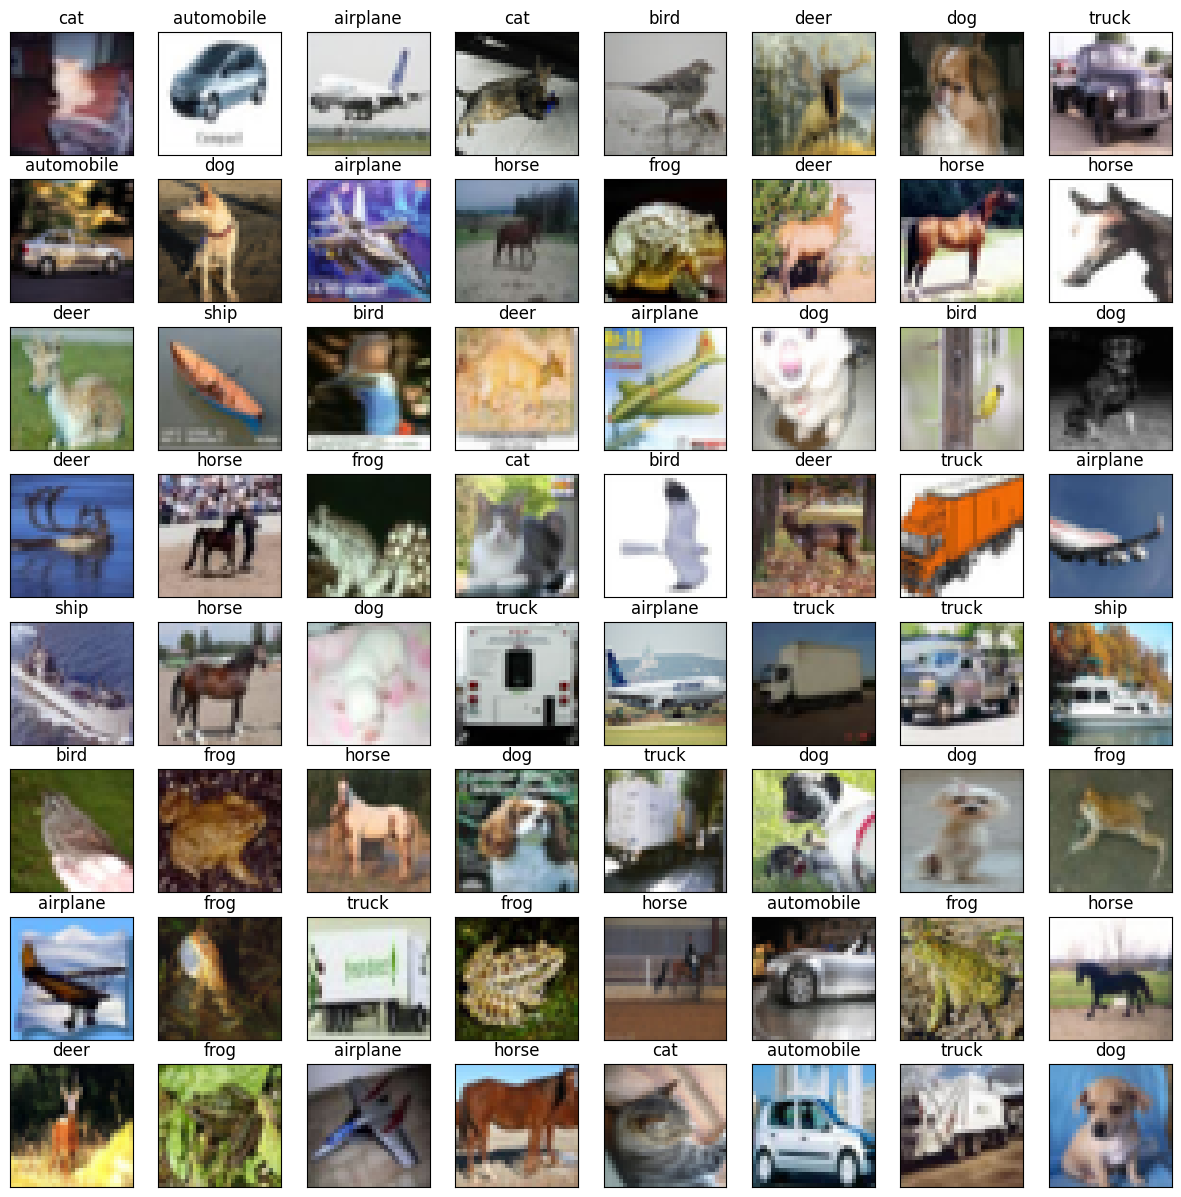

In [7]:
# CIFAR-10 classes 
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))

# loop over the first 64 images
for i in range(64):
    plt.subplot(8,8,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)


    plt.imshow(X_train[i])

    plt.title(class_names[y_train[i][0]], fontsize=12)

plt.show()

# Data Prepocessing
#### 1. Normalization of Data

In [8]:
# convert piXel values data type to float32 
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_valid = X_valid.astype('float32')

# centaring images by calculating mean and standard deviation of training set
mean = np.mean(X_train)
std = np.std(X_train)

# Normalize the data
# the tiny value 1e-7 (0.0000001) is added to prevent division ny zero
X_train = (X_train-mean)/(std+1e-7)
X_test = (X_test-mean)/(std+1e-7)
X_valid = (X_valid-mean)/(std+1e-7)

#### 2. Data Augmentation

In [9]:
data_generator = ImageDataGenerator(
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1)
    
)

I0000 00:00:1778274042.687799      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



# Define CNN Model Architecture 

In [10]:
model = Sequential()

weight_decay = 0.0001

model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu',kernel_regularizer=l2(weight_decay), input_shape=X_train.shape[1:]))
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu',kernel_regularizer=l2(weight_decay), input_shape=X_train.shape[1:]))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(rate=0.2))

model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(rate=0.3))

model.add(Conv2D(128,kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128,kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(rate=0.4))

model.add(Conv2D(256, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(Conv2D(256, kernel_size=(3,3), padding='same', activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(rate=0.5))


model.add(Flatten())
# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.1))
# model.add(Dense(32, activation='relu'))
# model.add(Dropout(0.1))
# model.add(Dense(18, activation='relu'))
# model.add(Dropout(0.1))

model.add(Dense(10, activation='softmax'))

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 2, 2, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 2, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,178,666 (4.50 MB)

 Trainable params: 1,176,746 (4.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [12]:
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [13]:
early_stopping = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1)
batch_size = 64
epochs=300
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)

In [14]:
history=model.fit(data_generator.flow(X_train,y_train, batch_size=batch_size),
                  epochs=epochs, 
                  validation_data=(X_valid, y_valid), 
                  callbacks=[reduce_lr, early_stopping], 
                  verbose=2)

Epoch 1/300


I0000 00:00:1778274050.418817      71 service.cc:152] XLA service 0x79be4400c8b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778274050.418869      71 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778274051.562214      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778274059.699704      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


704/704 - 30s - 42ms/step - accuracy: 0.3693 - loss: 2.2390 - val_accuracy: 0.4406 - val_loss: 1.6560 - learning_rate: 5.0000e-04
Epoch 2/300
704/704 - 6s - 8ms/step - accuracy: 0.5231 - loss: 1.4553 - val_accuracy: 0.5714 - val_loss: 1.2501 - learning_rate: 5.0000e-04
Epoch 3/300
704/704 - 6s - 8ms/step - accuracy: 0.6099 - loss: 1.1918 - val_accuracy: 0.5918 - val_loss: 1.2678 - learning_rate: 5.0000e-04
Epoch 4/300
704/704 - 6s - 8ms/step - accuracy: 0.6620 - loss: 1.0311 - val_accuracy: 0.6854 - val_loss: 0.9623 - learning_rate: 5.0000e-04
Epoch 5/300
704/704 - 6s - 8ms/step - accuracy: 0.7032 - loss: 0.9212 - val_accuracy: 0.6968 - val_loss: 0.9542 - learning_rate: 5.0000e-04
Epoch 6/300
704/704 - 6s - 8ms/step - accuracy: 0.7312 - loss: 0.8488 - val_accuracy: 0.7278 - val_loss: 0.8514 - learning_rate: 5.0000e-04
Epoch 7/300
704/704 - 6s - 8ms/step - accuracy: 0.7543 - loss: 0.7850 - val_accuracy: 0.7548 - val_loss: 0.7871 - learning_rate: 5.0000e-04
Epoch 8/300
704/704 - 6s - 8ms

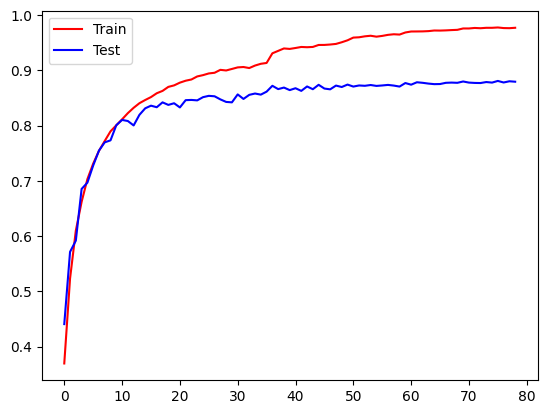

In [15]:
plt.plot(history.history['accuracy'], label='Train', color='red')
plt.plot(history.history['val_accuracy'], label='Test', color='blue')
plt.legend()
plt.show()

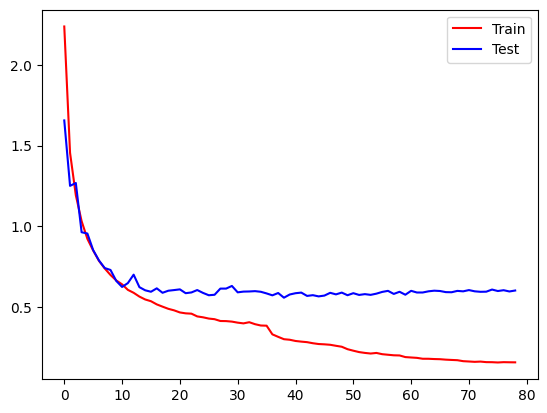

In [16]:
plt.plot(history.history['loss'], label='Train', color='red')
plt.plot(history.history['val_loss'], label='Test', color='blue')
plt.legend()
plt.show()

## Load Image for Predication

In [17]:
def predication(img_path):

    # load and display image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    
    # resize image
    img = cv2.resize(img, (32,32))

    # normalize image
    img = (img-mean)/(std+1e-7)

    # add an extra dimension
    img = np.expand_dims(img, axis=0)
    

    # predication
    res = model.predict(img)

    #find the highest probability
    pred_class = res.argmax()
    print('Predicated class: ', class_names[pred_class])
    
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicated class:  horse


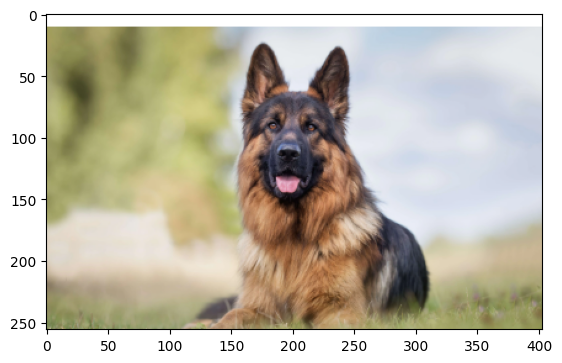

In [18]:
predication('/kaggle/input/datasets/openends/dog-png/dog3.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicated class:  truck


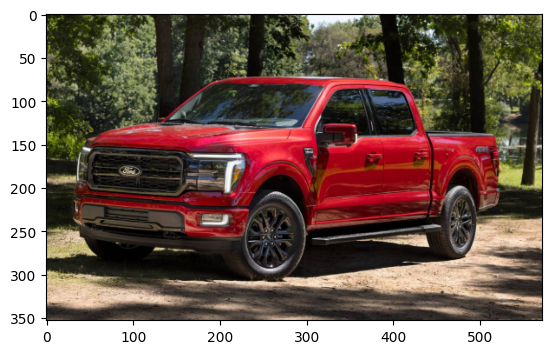

In [19]:
predication('/kaggle/input/datasets/openends/test-data/automobil.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicated class:  automobile


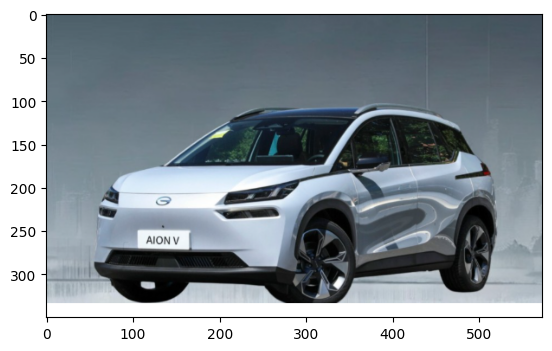

In [20]:
predication('/kaggle/input/datasets/openends/test-data/automobil2.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicated class:  frog


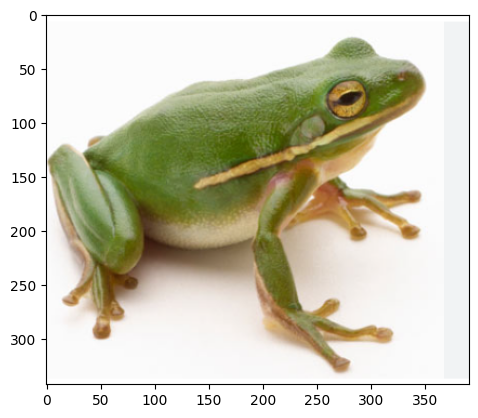

In [21]:
predication('/kaggle/input/datasets/openends/test-data/frog.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicated class:  cat


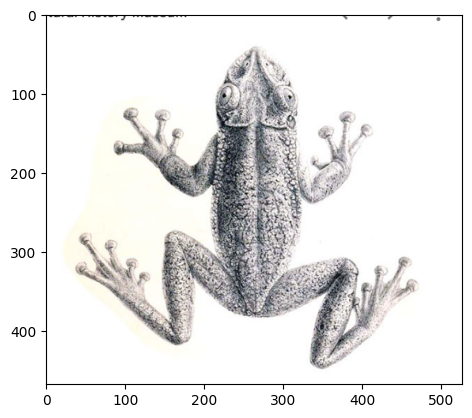

In [22]:
predication('/kaggle/input/datasets/openends/test-data/frog2.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicated class:  horse


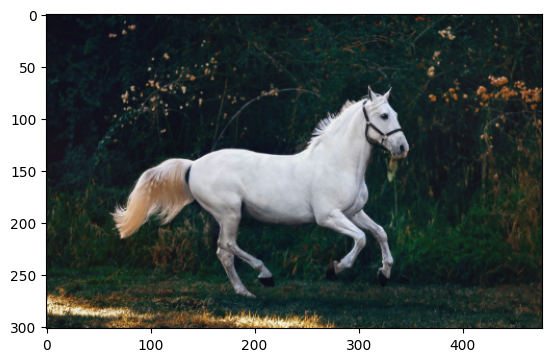

In [23]:
predication('/kaggle/input/datasets/openends/test-data/horse.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicated class:  airplane


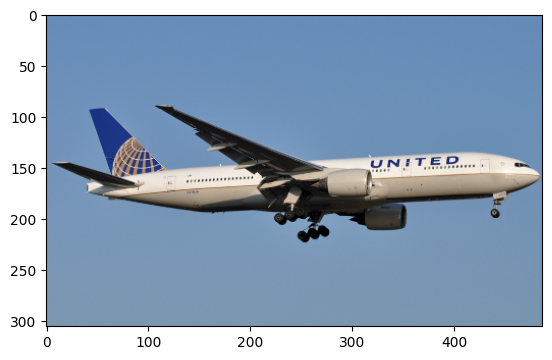

In [24]:
predication('/kaggle/input/datasets/openends/test-data/plane.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicated class:  airplane


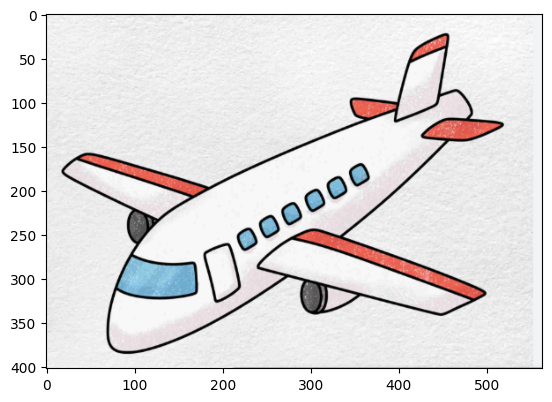

In [25]:
predication('/kaggle/input/datasets/openends/test-data/plane2.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicated class:  ship


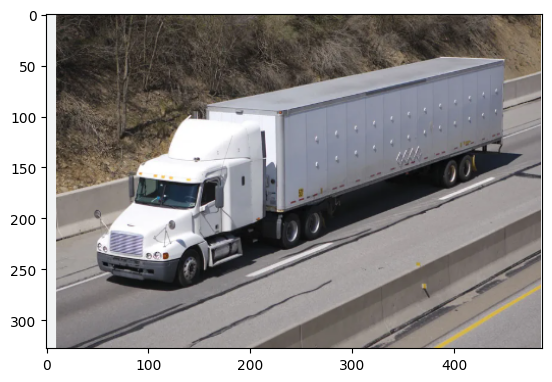

In [26]:
predication('/kaggle/input/datasets/openends/test-data/truck.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicated class:  ship


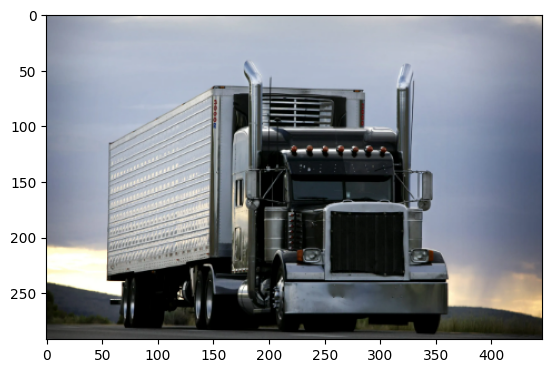

In [27]:
predication('/kaggle/input/datasets/openends/test-data/truck2.png')